In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import pathlib
import gc
import warnings
warnings.filterwarnings('ignore')

seed = 42
np.random.seed(seed)


ROOT = pathlib.Path().resolve()
DATA_FOLDER = ROOT / "data/bike"

print(DATA_FOLDER)


C:\Users\PatCa\Documents\PythonScripts\test_projects\big_data\bike_data\data\bike


In [87]:
df = pd.read_parquet('all_years_weekly.parquet')

In [88]:
def plot_(y_true, y_pred):

    xx = range(len(y_pred))

    plt.figure(figsize=(12,7))
    plt.plot(xx, y_true, marker='.')
    plt.plot(xx, y_pred, marker='x', linestyle = 'None')
    plt.show()

from sklearn import metrics

def met_(y_true, y_pred):
    ev = metrics.explained_variance_score(y_true, y_pred)
    mape_ = metrics.mean_absolute_percentage_error(y_true, y_pred)
    mae_ = metrics.mean_absolute_error(y_true, y_pred)
    rms = np.sqrt(metrics.mean_squared_error(y_true, y_pred))

    print(f'explained variance: {ev:.2f}, mape: {mape_:.2f}, mae: {mae_:.2f}, rms: {rms:.2f}')
    return
    


# Persistance Model
Predict one time step previous

In [89]:
test_length = int(df.shape[0] * 0.1)
train = df.iloc[:-test_length,:].dropna()
test = df.iloc[-test_length:,:].dropna()
display(test.head(3))

,count_trips,start_tripduration
starttime,,
2019-06-09,556172,628571676
2019-06-16,459348,514596603
2019-06-23,450376,468333940


In [90]:
#Prediction 1 timestep forward
y_pred = test['count_trips'].to_numpy()[:-1] 
y_true = test['count_trips'].to_numpy()[1:] 

print(y_pred.shape, y_true.shape)

(30,) (30,)


explained variance: 0.86, mape: 0.20, mae: 42781.60, rms: 54170.64


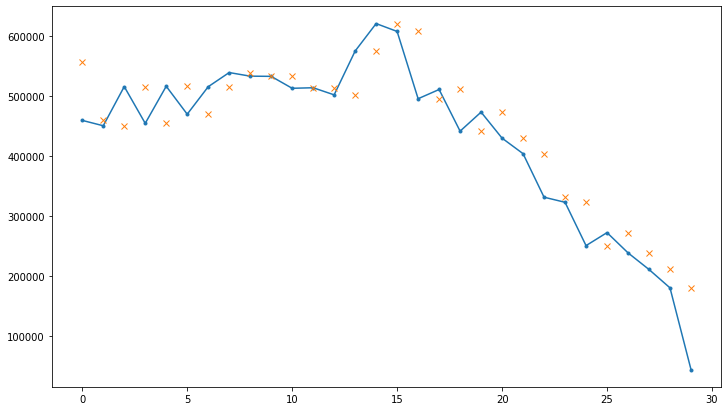

In [91]:
met_(y_true, y_pred)
plot_(y_true,y_pred)

In [92]:
# Prediction 4 timesteps forward
y_all = test['count_trips'].to_numpy()
y_pred = test['count_trips'].to_numpy()[:-4].astype('float') 
y_pred_plot = np.append([np.nan, np.nan, np.nan, np.nan], y_pred)
y_true = test['count_trips'].to_numpy()[4:] 
print(y_pred.shape, y_true.shape)

(27,) (27,)


explained variance: 0.60, mape: 0.41, mae: 84429.04, rms: 102245.48


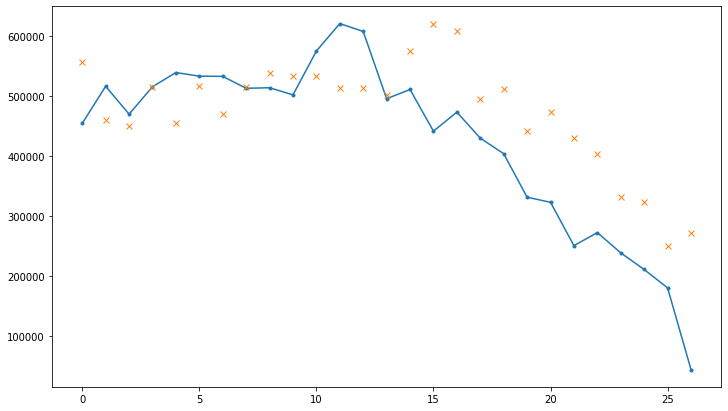

In [93]:
met_(y_true, y_pred)
plot_(y_true,y_pred)

In [94]:
# Check persistance model from last year
persist_length = test_length + 52
y_pred = df.iloc[-persist_length:-52,:]['count_trips'].to_numpy()
y_true = test['count_trips'].to_numpy()

print(y_pred.shape, y_true.shape)
print(y_pred[:3], y_true[:3])

(31,) (31,)
[450713 476293 457761] [556172 459348 450376]


explained variance: 0.75, mape: 0.27, mae: 69936.55, rms: 84745.23


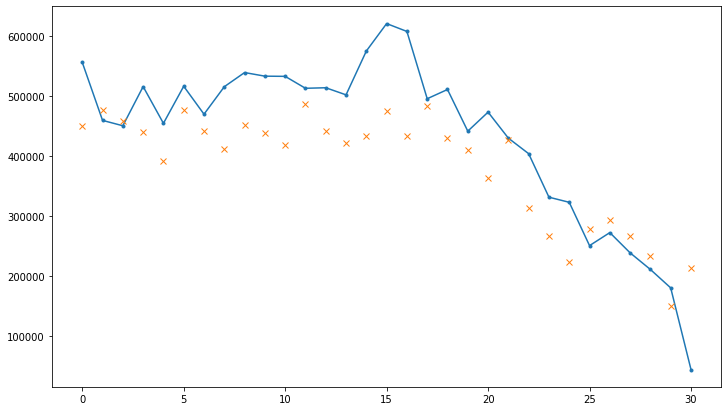

In [95]:
met_(y_true, y_pred)
plot_(y_true,y_pred)